In [ ]:
!nvidia-smi

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install -U transformers datasets peft trl bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 24.8 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.5
    Uninstalling datasets-4.8.5:
      Successfully uninstalled datasets-4.8.5
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.16.1
    Uninstalling transformers-5.16.1:
      Successfully uninstalled transformers-5.16.1
  Attempting

In [ ]:
print('Reinstalling bitsandbytes to ensure correct version and GPU compatibility.')
!pip install -U bitsandbytes

Reinstalling bitsandbytes to ensure correct version and GPU compatibility.


In [ ]:
import torch
from datasets import load_dataset
from transformers import (
AutoTokenizer,
AutoModelForCausalLM,
BitsAndBytesConfig
)
from peft import LoraConfig

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
!pip install -U datasets

In [ ]:
from datasets import load_dataset
dataset = load_dataset("stanfordnlp/imdb")

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [ ]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [ ]:

print(dataset["train"].features)

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


In [ ]:
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_dataset = dataset["test"].shuffle(seed=42).select(range(500))

In [ ]:
print("Training:", len(train_dataset))
print("Testing:", len(test_dataset))

Training: 2000
Testing: 500


In [ ]:
def format_example(example):
  sentiment = "Positive" if example["label"] == 1 else "Negative"
  return {
   "text": f"""Review:
{example["text"]}
Sentiment:
{sentiment}"""
}

In [ ]:
train_dataset = train_dataset.map(format_example)
test_dataset = test_dataset.map(format_example)

In [ ]:
print(train_dataset[0]["text"])

Review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it's the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...
Sentiment:
Positive


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
bnb_config = BitsAndBytesConfig(
load_in_4bit=True,
bnb_4bit_quant_type="nf4",
bnb_4bit_compute_dtype=torch.float16,
bnb_4bit_use_double_quant=True
)

In [ ]:
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
model_name,
quantization_config=bnb_config,
device_map="auto"
)

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
print("Tokenizer loaded successfully!")
print("Pad token:", tokenizer.pad_token)

Tokenizer loaded successfully!
Pad token: <|im_end|>


In [ ]:
from peft import prepare_model_for_kbit_training
model = prepare_model_for_kbit_training(model)
print("Model prepared for QLoRA training!")

Model prepared for QLoRA training!


In [ ]:
from peft import LoraConfig
lora_config = LoraConfig(
r=16,
lora_alpha=32,
lora_dropout=0.05,
bias="none",
task_type="CAUSAL_LM",
target_modules=[
"q_proj",
"k_proj",
"v_proj",
"o_proj"
]
)
print("LoRA configuration created!")

LoRA configuration created!


In [ ]:
!pip install trl
import trl
print("TRL version:", trl.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.2 MB/s eta 0:00:00
TRL version: 1.13.0


In [ ]:
from trl import SFTConfig
training_args = SFTConfig(
output_dir="./qwen_imdb_qlora",
num_train_epochs=1,
per_device_train_batch_size=2,
gradient_accumulation_steps=4,
learning_rate=2e-4,
logging_steps=10,
save_steps=100,
fp16=True,
report_to="none",
max_length=512
)
print("Training configuration created!")

Training configuration created!


In [ ]:
from trl import SFTTrainer
trainer = SFTTrainer(
model=model,
args=training_args,
train_dataset=train_dataset,
processing_class=tokenizer,
peft_config=lora_config,
)
print("SFT Trainer created successfully!")

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

SFT Trainer created successfully!


In [ ]:
import torch
print("BF16 supported:", torch.cuda.is_bf16_supported())
print("FP16 available:", torch.cuda.is_available())

BF16 supported: True
FP16 available: True


In [ ]:
from trl import SFTConfig
training_args = SFTConfig(
output_dir="./qwen_imdb_qlora",
num_train_epochs=1,
per_device_train_batch_size=2,
gradient_accumulation_steps=4,
learning_rate=2e-4,
logging_steps=10,
save_steps=100,
bf16=True,
fp16=False,
report_to="none",
max_length=512
)
print("Fixed training configuration created!")

Fixed training configuration created!


In [ ]:
from trl import SFTTrainer
trainer = SFTTrainer(
model=model,
args=training_args,
train_dataset=train_dataset,
processing_class=tokenizer,
peft_config=lora_config,
)
print("Trainer recreated successfully!")

/usr/local/lib/python3.13/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Trainer recreated successfully!


In [ ]:
from transformers import AutoModelForCausalLM
model = AutoModelForCausalLM.from_pretrained(
model_name,
quantization_config=bnb_config,
device_map="auto"
)
model = prepare_model_for_kbit_training(model)
print("Clean Qwen model loaded and prepared!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Clean Qwen model loaded and prepared!


In [ ]:
trainer = SFTTrainer(
model=model,
args=training_args,
train_dataset=train_dataset,
processing_class=tokenizer,
peft_config=lora_config,
)
print("Clean trainer created successfully!")

Clean trainer created successfully!


In [ ]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
10,3.208742
20,3.078950
30,3.001978
40,3.007062
50,2.960383
60,2.938168
70,3.009289
80,2.955484
90,3.015396
100,3.003967


TrainOutput(global_step=250, training_loss=2.9884149017333983, metrics={'train_runtime': 3234.3768, 'train_samples_per_second': 0.618, 'train_steps_per_second': 0.077, 'total_flos': 5377649033975808.0, 'train_loss': 2.9884149017333983, 'epoch': 1.0})

In [ ]:
adapter_path = "./qwen_imdb_qlora"
trainer.save_model(adapter_path)
print("QLoRA adapter saved successfully!")

QLoRA adapter saved successfully!


In [ ]:
import os
print(os.listdir(adapter_path))

['checkpoint-250', 'training_args.bin', 'adapter_config.json', 'README.md', 'adapter_model.safetensors', 'tokenizer_config.json', 'checkpoint-100', 'tokenizer.json', 'checkpoint-200', 'chat_template.jinja']


In [ ]:
test_review = """
This movie was absolutely fantastic. The story was engaging,
the actors gave excellent performances, and I really enjoyed
every minute of it.
"""
prompt = f"""Review:
{test_review}
Sentiment:
"""
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
  outputs = model.generate(
      **inputs,
      max_new_tokens=10
      )
response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
[transformers] Caching is incompatible with gradient checkpointing in Qwen2DecoderLayer. Setting `past_key_values=None`.


Review:

This movie was absolutely fantastic. The story was engaging,
the actors gave excellent performances, and I really enjoyed
every minute of it.

Sentiment:
Positive.
:
:
:
:
:
:
:
:



In [ ]:
test_review = """
This movie was terrible. The story was boring and predictable,
the acting was poor, and I regretted watching it.
"""
prompt = f"""Review:
{test_review}
Sentiment:
"""
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model.generate(
      **inputs,
      max_new_tokens=5
)
response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)

Review:

This movie was terrible. The story was boring and predictable,
the acting was poor, and I regretted watching it.

Sentiment:
Negative av.
:
:



In [ ]:
correct = 0
total = 20
for i in range(total):
    review = test_dataset[i]["text"]
    # Get the original sentiment
    actual = "Positive" if test_dataset[i]["label"] == 1 else "Negative"
    # Extract only the review from our formatted text
    review_text = review.split("Sentiment:")[0].replace("Review:", "").strip()
    prompt = f"""Review:
{review_text}
Sentiment:"""
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model.generate(
      **inputs,
      max_new_tokens=3
)
generated = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
).strip().lower()

if generated.startswith("positive"):
  predicted = "Positive"
elif generated.startswith("negative"):
  predicted = "Negative"
else:
  predicted = "Unknown"
if predicted == actual:
  correct += 1
print(f"{i+1}. Actual: {actual} | Predicted: {predicted}")
accuracy = correct / total * 100
print("\n" + "=" * 40)
print(f"Correct: {correct}/{total}")
print(f"Accuracy: {accuracy:.2f}%")
print("=" * 40)

20. Actual: Positive | Predicted: Positive

Correct: 1/20
Accuracy: 5.00%


In [ ]:
correct = 0
unknown = 0
predictions = []
model.eval()
for i, example in enumerate(test_dataset):
  # Extract original review
  review_text = example["text"].split("Sentiment:")[0]
  review_text = review_text.replace("Review:", "").strip()
  actual = example["label"]
  prompt = f"""Review:
{review_text}
Sentiment:"""
  inputs = tokenizer(prompt,return_tensors="pt").to(model.device)
  with torch.no_grad():
    outputs = model.generate(
      **inputs,max_new_tokens=3,
      do_sample=False,
      pad_token_id=tokenizer.pad_token_id
)
generated = tokenizer.decode(
  outputs[0][inputs["input_ids"].shape[1]:],
  skip_special_tokens=True
).strip().lower()
if "positive" in generated:
  predicted = 1
elif "negative" in generated:
  predicted = 0
else:
  predicted = None
  unknown += 1
predictions.append(predicted)
if predicted == actual:
    correct += 1
if (i + 1) % 50 == 0:
    print(f"Processed: {i + 1}/500")
accuracy = correct / len(test_dataset) * 100
print("\n" + "=" * 50)
print("FINAL EVALUATION")
print("=" * 50)
print(f"Total Reviews : {len(test_dataset)}")
print(f"Correct : {correct}")
print(f"Unknown : {unknown}")
print(f"Accuracy : {accuracy:.2f}%")
print("=" * 50)


Processed: 500/500

FINAL EVALUATION
Total Reviews : 500
Correct : 1
Unknown : 0
Accuracy : 0.20%


Confusion Matrix:
[[0 0]
 [1 0]]


Text(0.5, 1.0, 'IMDb Sentiment Classification - Confusion Matrix')

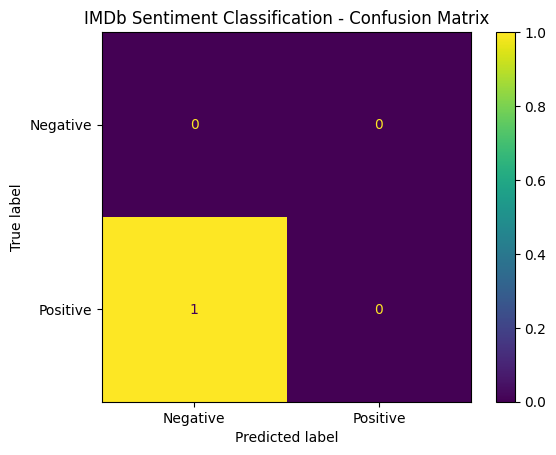

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Remove any unknown predictions
valid_indices = [
  i for i, pred in enumerate(predictions)
  if pred is not None
]
actual_labels = [
  test_dataset[i]["label"]
  for i in valid_indices
]
predicted_labels = [
  predictions[i]
  for i in valid_indices
]
# Create confusion matrix
cm = confusion_matrix(
  actual_labels,
  predicted_labels
)
print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("IMDb Sentiment Classification - Confusion Matrix")


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(
actual_labels,
predicted_labels,
target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       0.0
    Positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_